##Aditya Vardhan Chenna
## Mtech Data Science
## Image_Noise_Reduction using Tensorflow, with AutoEncoders

In [ ]:
!nvidia-smi

Tue Mar 26 09:11:11 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   59C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
from tensorflow.keras.datasets import mnist

11490434/11490434 [==============================] - 0s 0us/step
Training data shapes: X=(60000, 28, 28), y=(60000,)
Testing data shapes: X=(10000, 28, 28), y=(10000,)


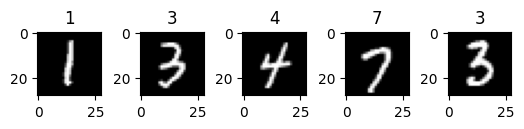

In [ ]:
(trainX, trainy), (testX, testy) = mnist.load_data()
print('Training data shapes: X=%s, y=%s' % (trainX.shape, trainy.shape))
print('Testing data shapes: X=%s, y=%s' % (testX.shape, testy.shape))
for j in range(5):
    i = np.random.randint(0, 10000)
    plt.subplot(550 + 1 + j)
    plt.imshow(trainX[i], cmap='gray')
    plt.title(trainy[i])
plt.show()

## Adding Noise to the dataset


In [ ]:
def guassian_noise(image):
    r,c= image.shape
    mean = 0
    var = 0.1
    sigma = var**0.5
    gaussian = np.random.normal(mean,sigma,(r,c))
    gaussian = gaussian.reshape(r,c)
    noisy = image + gaussian
    return noisy

In [ ]:
def salt_and_pepper_noise(image):
    ratio = 0.9
    amount = 0.1
    noisy = np.copy(image)

    salt_count = np.ceil(amount * image.size * ratio)
    coords = [np.random.randint(0, i - 1, int(salt_count)) for i in image.shape]
    noisy[coords] = 1
    pepper_count = np.ceil(amount* image.size * (1. - ratio))
    coords = [np.random.randint(0, i - 1, int(pepper_count)) for i in image.shape]
    noisy[coords] = 0
    return noisy
def poisson_noise(image):
    vals = len(np.unique(image))
    vals = 2 ** np.ceil(np.log2(vals))
    noisy = np.random.poisson(image * vals) / float(vals)
    return noisy
def speckle_noise(image):
    r,c = image.shape
    speckle = np.random.randn(r,c)
    speckle = speckle.reshape(r,c)
    noisy = image + image * speckle
    return noisy
def add_noise(image):
    p = np.random.random()
    if p <= 0.25:
        print("Guassian")
        noisy = guassian_noise(image)
    elif p <= 0.5:
         print("SnP")
         noisy = salt_and_pepper_noise(image)
    elif p <= 0.75:
         print("Poison")
         noisy = poisson_noise(image)
    else:
          print("speckle")
          noisy = speckle_noise(image)
    return noisy

Corrupted Example Samples
SnP
speckle
Guassian
Poison
SnP
speckle
SnP
Guassian
Poison


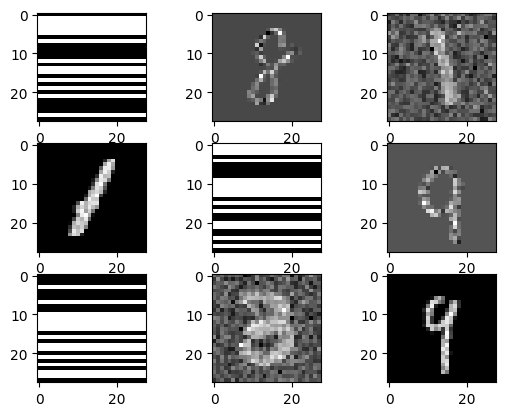

In [ ]:
print ("Corrupted Example Samples")
for j in range(9):
    i = np.random.randint(0, 10000)
    plt.subplot(330 + 1 + j)
    noisy = add_noise(trainX[i]/255)
    plt.imshow(noisy, cmap='gray')
plt.show()

#Data Preparation

In [ ]:
train_clean = [image/255 for image in trainX]
test_clean = [image/255 for image in testX]

In [ ]:
train_noisy = [add_noise(image/255) for image in trainX]
test_noisy = [add_noise(image/255) for image in testX]
train_clean = np.reshape(train_clean, (60000, 28, 28, 1))
test_clean = np.reshape(test_clean, (10000, 28, 28, 1))
train_noisy = np.reshape(train_noisy, (60000, 28, 28, 1))
test_noisy = np.reshape(test_noisy, (10000, 28, 28, 1))
print (train_clean.shape, train_noisy.shape, test_clean.shape, test_noisy.shape)

Streaming output truncated to the last 5000 lines.
Guassian
Poison
Guassian
Guassian
SnP
SnP
Guassian
Guassian
SnP
speckle
Poison
speckle
speckle
SnP
speckle
SnP
SnP
Guassian
Guassian
SnP
speckle
Guassian
SnP
SnP
Poison
Poison
Guassian
speckle
Guassian
speckle
speckle
speckle
speckle
SnP
SnP
SnP
speckle
speckle
speckle
Poison
Guassian
SnP
Poison
Poison
Guassian
SnP
speckle
Guassian
Guassian
speckle
Guassian
Poison
Poison
SnP
Poison
SnP
SnP
Guassian
speckle
Poison
speckle
speckle
Poison
Poison
Poison
SnP
Guassian
speckle
SnP
Poison
speckle
SnP
SnP
speckle
SnP
SnP
SnP
SnP
Poison
speckle
Guassian
Guassian
Guassian
Poison
speckle
SnP
SnP
SnP
Poison
Guassian
SnP
Poison
Poison
SnP
speckle
speckle
Poison
speckle
SnP
Poison
Poison
Poison
SnP
SnP
speckle
Guassian
SnP
SnP
speckle
SnP
Guassian
SnP
Poison
Poison
SnP
speckle
SnP
Poison
Guassian
Poison
Poison
SnP
SnP
SnP
Guassian
Guassian
SnP
SnP
Poison
Poison
Guassian
SnP
Guassian
Guassian
speckle
SnP
Guassian
Guassian
SnP
Poison
speckle
Guassian
G

#Training Convolutional Denoising Autoencoder

In [ ]:
import tensorflow

In [ ]:
input_data = tensorflow.keras.layers.Input(shape=(28, 28, 1))
#Encoder part
encoder = tensorflow.keras.layers.Conv2D(64, (5,5), activation='relu')(input_data)
encoder = tensorflow.keras.layers.MaxPooling2D((2,2))(encoder)
encoder = tensorflow.keras.layers.Conv2D(128, (3,3), activation='relu')(encoder)
encoder = tensorflow.keras.layers.MaxPooling2D((2,2))(encoder)
encoder = tensorflow.keras.layers.Conv2D(256, (3,3), activation='relu')(encoder)
encoder = tensorflow.keras.layers.MaxPooling2D((2,2))(encoder)
#Decoder Part
decoder = tensorflow.keras.layers.Conv2DTranspose(256, (3,3), activation='relu')(encoder)
decoder = tensorflow.keras.layers.Conv2DTranspose(128, (3,3), activation='relu')(decoder)
decoder = tensorflow.keras.layers.UpSampling2D((2,2))(decoder)
decoder = tensorflow.keras.layers.Conv2DTranspose(64, (3,3), activation='relu')(decoder)
decoder = tensorflow.keras.layers.UpSampling2D((2,2))(decoder)
decoded = tensorflow.keras.layers.Conv2DTranspose(1, (5,5), activation='relu')(decoder)

In [ ]:
autoencoder = tensorflow.keras.models.Model(inputs=input_data, outputs=decoded)
autoencoder.compile(loss='mse', optimizer='adam')
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 24, 24, 64)        1664      
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 128)       73856     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 128)         0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 256)         295168

#Training

In [ ]:
autoencoder.fit(train_noisy, train_clean, epochs=100, batch_size=64, validation_data=(test_noisy, test_clean))

Epoch 1/100
938/938 [==============================] - 15s 9ms/step - loss: 0.0404 - val_loss: 0.0297
Epoch 2/100
938/938 [==============================] - 8s 8ms/step - loss: 0.0274 - val_loss: 0.0266
Epoch 3/100
938/938 [==============================] - 8s 8ms/step - loss: 0.0255 - val_loss: 0.0253
Epoch 4/100
938/938 [==============================] - 8s 9ms/step - loss: 0.0245 - val_loss: 0.0248
Epoch 5/100
938/938 [==============================] - 8s 8ms/step - loss: 0.0240 - val_loss: 0.0245
Epoch 6/100
938/938 [==============================] - 7s 8ms/step - loss: 0.0235 - val_loss: 0.0239
Epoch 7/100
938/938 [==============================] - 8s 8ms/step - loss: 0.0232 - val_loss: 0.0235
Epoch 8/100
938/938 [==============================] - 8s 8ms/step - loss: 0.0229 - val_loss: 0.0239
Epoch 9/100
938/938 [==============================] - 8s 8ms/step - loss: 0.0227 - val_loss: 0.0233
Epoch 10/100
938/938 [==============================] - 9s 10ms/step - loss: 0.0225 - val_

Real Test Images


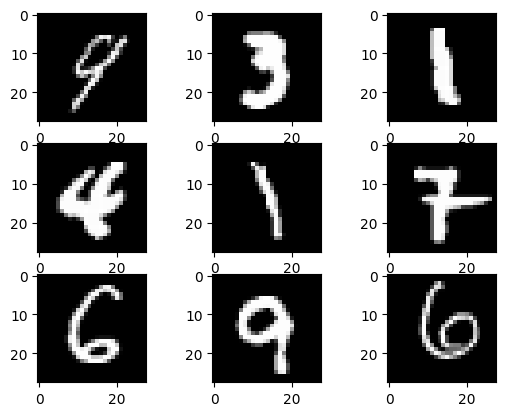

In [ ]:
offset=92
print ("Real Test Images")
# Real Images
for i in range(9):
     plt.subplot(330 + 1 + i)
     plt.imshow(test_clean[i+offset,:,:, -1], cmap='gray')
plt.show()

Noisy test images


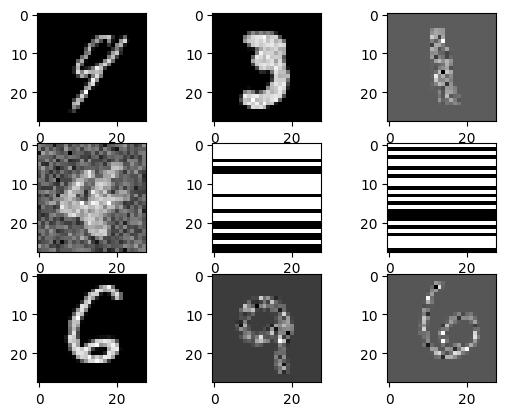

Cleaned Version(Denoising Autoencoder):) 
1/1 [==============================] - 0s 19ms/step


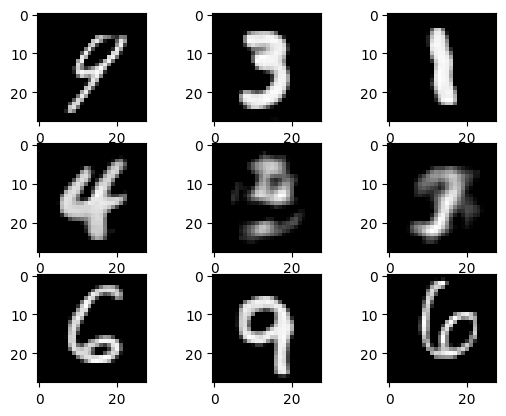

In [ ]:
print("Noisy test images")
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(test_noisy[i+offset,:,:, -1], cmap='gray')
plt.show()
# Reconstructed Images
print ("Cleaned Version(Denoising Autoencoder):) ")
for i in range(9):
    plt.subplot(330 + 1 + i)
    output = autoencoder.predict(np.array([test_noisy[i+offset]]))
    op_image = np.reshape(output[0]*255, (28, 28))
    plt.imshow(op_image, cmap='gray')
plt.show()